### Load in RNA Data

Loads CosMX RNA expression data. Will take several minutes

In [45]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

TMA_Core="A"
#Load files on desktop
expr= pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
#expr=expr_orig.transpose()
metadata = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
umap = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

# Extra - MetaData File
extra_metadata=pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\Run_TMA{TMA_Core}_metadata_file.csv", index_col=0)

#Load files on Lab computer

# expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAexpression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAmetadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAumap.csv", index_col=0)

#Load files on laptop
# expr= pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMAA_transposed.csv", index_col=0)
# #expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMAA_meta_transposed.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMAA_umap_transposed.csv", index_col=0)

# Create AnnData object
adata_rna = sc.AnnData(X=expr.values)

# Assign metadata
adata_rna.obs = metadata
adata_rna.var_names = expr.columns
adata_rna.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata_rna.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
# x_pixel, y_pixel, x_norm	y_norm	x_micron	y_micron x_cent	y_cent

adata_rna.obsm["X_umap"] = umap.values

# Display General Data on the imported data. Run the import first
display(expr.columns)
display(expr.index)



Index(['ABL1', 'ABL2', 'ACE', 'ACE2', 'ACKR1', 'ACKR3', 'ACKR4', 'ACTA2',
       'ACTG2', 'ACVR1',
       ...
       'NegPrb13', 'NegPrb14', 'NegPrb15', 'NegPrb16', 'NegPrb18', 'NegPrb19',
       'NegPrb20', 'NegPrb21', 'NegPrb22', 'NegPrb23'],
      dtype='object', length=978)

Index(['__Run5607.TMAA_1_1', '__Run5607.TMAA_2_1', '__Run5607.TMAA_3_1',
       '__Run5607.TMAA_4_1', '__Run5607.TMAA_5_1', '__Run5607.TMAA_6_1',
       '__Run5607.TMAA_7_1', '__Run5607.TMAA_8_1', '__Run5607.TMAA_9_1',
       '__Run5607.TMAA_10_1',
       ...
       '__Run5607.TMAA_3593_25', '__Run5607.TMAA_3594_25',
       '__Run5607.TMAA_3595_25', '__Run5607.TMAA_3597_25',
       '__Run5607.TMAA_3599_25', '__Run5607.TMAA_3600_25',
       '__Run5607.TMAA_3601_25', '__Run5607.TMAA_3602_25',
       '__Run5607.TMAA_3603_25', '__Run5607.TMAA_3604_25'],
      dtype='object', length=85390)

## Ligand Receptor Pairs

We want to examine how different ligand and recetor pairs are expressed spatially


<img src="./Images/ReceptorPairImage.png" alt="Receptor Pair Image" width="800"/>

There are 3 Main pairs I want to examine:
1. CXCL9/CXCL10-CXCR3
   * Main ligand expressing: Monocytes, endothelial, fibroblasts
   * Main receptor expressing cell: T-cells (activated), NKs, DCs, Bcells
   * Functions: Recruitment of Th1 and cytotoxic T cells, NK cells to inflamed tissues; Th1 immunity
3. CXCL16-CXCR6
   * Main ligand expressing: DCs, Monocytes/Macrophages, Bcells, Epithelial/Endothelial
   * Main receptor expressing cell: CD8, CD4, NKT cells, plasma, monocytes
   * Functions: Recruitment/retention of tissue-resident T cells, NKT cells; immune surveillance, tumor immunity
5. CCL4-CCR5
   * Main ligand expressing: T cells, monocytes/macrophages, NKs
   * Main receptor expressing cell: T cells, monocytes/macrophages, NK cells, DCs
   * Functions: Chemotaxis of effector T cells, monocytes, NK cells to inflammation; amplifies immune response





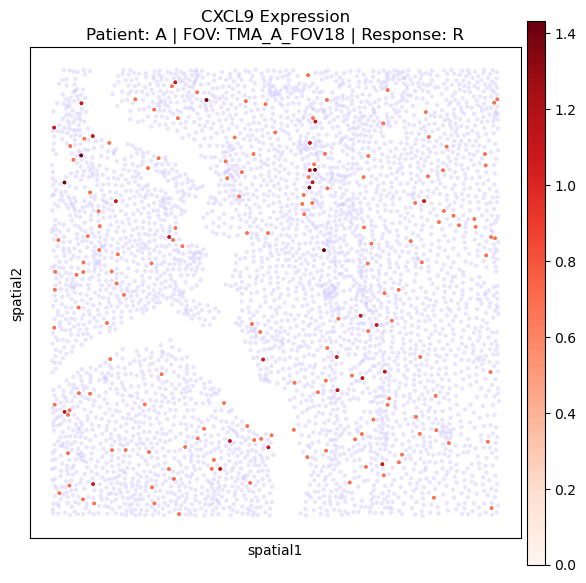

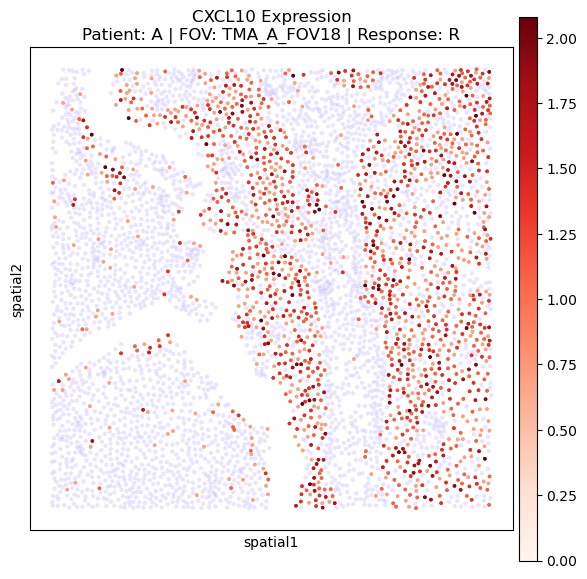

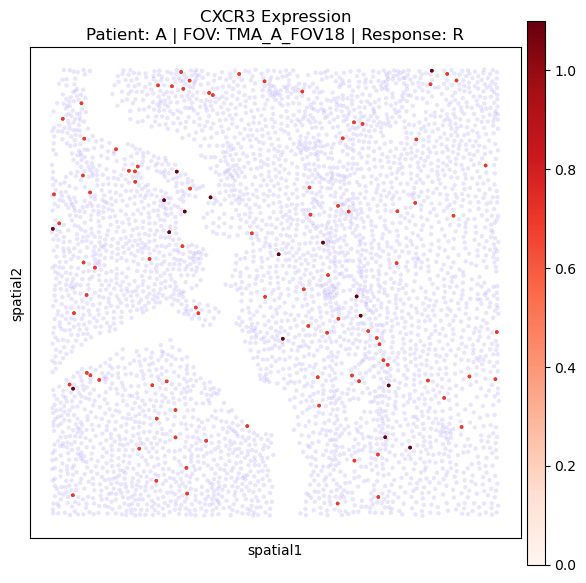

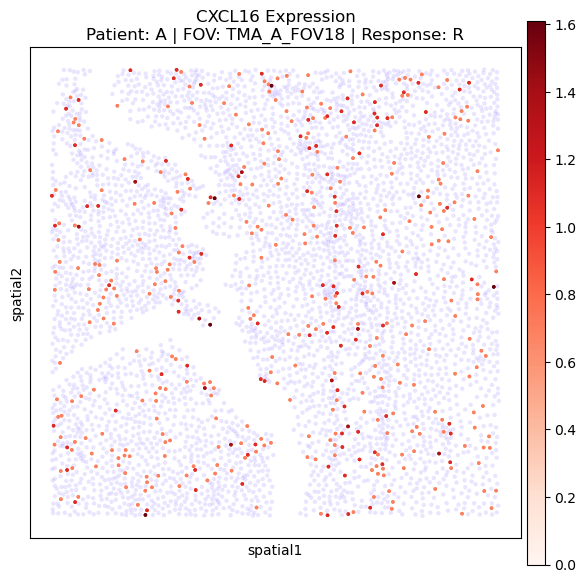

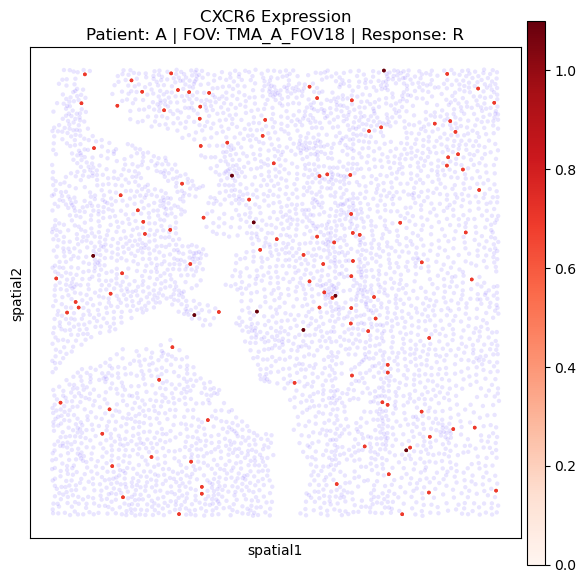

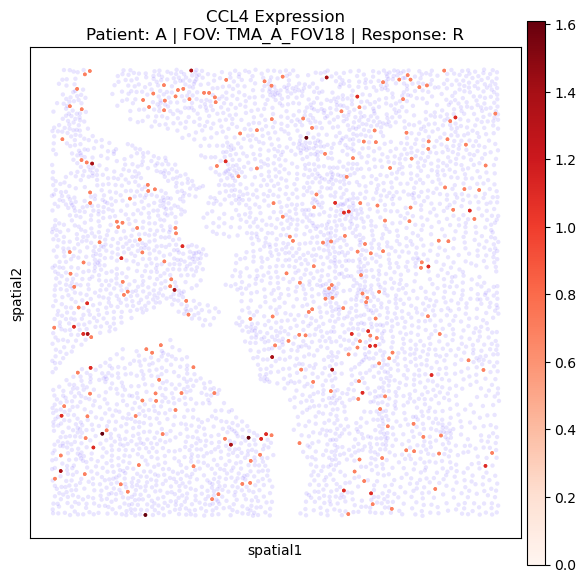

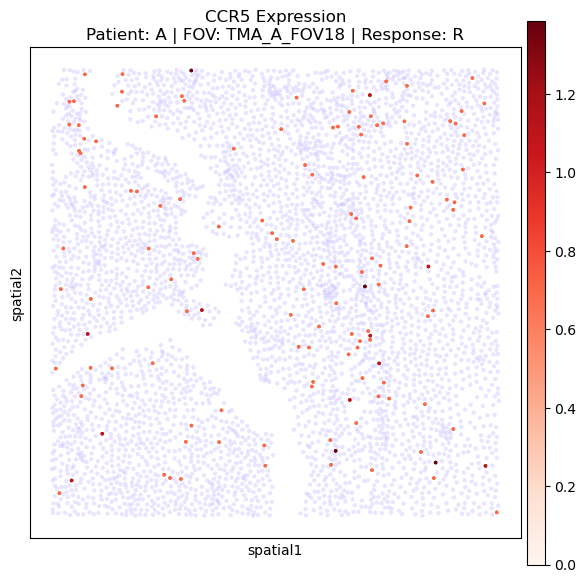

In [47]:
import my_functions
import squidpy as sq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

cell_ID_like = r"TMA_A_FOV18" #(?!\d)
genes_to_plot = ["CXCL9", "CXCL10", "CXCR3", "CXCL16", "CXCR6", "CCL4", "CCR5"]

# Subset sample
subset = adata_rna[adata_rna.obs.tma_fov_id.str.contains(cell_ID_like)]
patient_id = subset.obs["PatientID"].unique()[0]
response_status = subset.obs["Response"].unique()[0]
subset.obs["annot_cluster2"] = subset.obs["annot_cluster2"].astype("category")

for gene in genes_to_plot:
    if gene not in adata_rna.var_names:
        print(f"⚠️ Gene {gene} not found in dataset. Skipping.")
        continue

    # Get expression values
    gene_values = subset[:, gene].X
    if hasattr(gene_values, "toarray"):
        gene_values = gene_values.toarray().flatten()
    else:
        gene_values = gene_values.flatten()

    subset.obs[f"{gene}_expression"] = gene_values
    subset.obs["expr_mask"] = gene_values > 0

    fig, ax = plt.subplots(figsize=(6, 6))

    # Manually create the scatter plot for background cells
    non_expr_coords = subset.obsm["spatial"][~subset.obs["expr_mask"]]
    ax.scatter(
        non_expr_coords[:, 0],
        non_expr_coords[:, 1],
        color="#2F00FF",   # Set your desired background color here
        s=10,
        alpha=0.1,
        edgecolors="none"
    )


    # Overlay: expressing cells in color
    vmax = np.percentile(gene_values[gene_values > 0], 99)
    sq.pl.spatial_scatter(
        subset[subset.obs["expr_mask"]],
        color=f"{gene}_expression",
        shape=None,
        size=10,
        ax=ax,
        cmap="Reds",  # You can use 'plasma', 'viridis', etc.
        vmin=0,
        vmax=vmax  # Set based on expected expression range
    )

    ax.invert_yaxis()
    ax.set_title(f"{gene} Expression\nPatient: {patient_id} | FOV: {cell_ID_like} | Response: {response_status}")

    plt.tight_layout()
    plt.show()



In [43]:
# def matching_global_coordinate():

# def find_matching_global_coords(extra_metadata,cell_num,FOV_num):
#     import numpy as np
    
#     # Example: filter the structured array
#     filtered_row = extra_metadata[(extra_metadata.index == FOV_num) & (extra_metadata['cell_ID'] == cell_num)]
    
#     global_x=filtered_row['CenterX_global_px']*0.168*0.001
#     global_y=filtered_row['CenterY_global_px']*0.168*0.001

#     display(global_x)
#     display(global_y)
    
#     return{
#         "Global X":global_x,
#         "Global Y":global_y
#     }

def find_matching_global_coords(extra_metadata, cell_num, FOV_num):
    import numpy as np
    import pandas as pd
    
    # Ensure the index is reset so FOV becomes a column (if needed)
    filtered_row = extra_metadata.reset_index()
    filtered_row = filtered_row[(filtered_row['fov'] == FOV_num) & (filtered_row['cell_ID'] == cell_num)]

    if filtered_row.empty:
        print(f"No match found for FOV={FOV_num} and cell_ID={cell_num}.")
        return None

    global_x = filtered_row['CenterX_global_px'].values[0] * 0.168 * 0.001
    global_y = filtered_row['CenterY_global_px'].values[0] * 0.168 * 0.001

    display(global_x)
    display(global_y)

    return {
        "Global X": global_x,
        "Global Y": global_y
    }


def find_area_mRNA(adata,sample_id):
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]
    area=1

    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        
        # Updated regular expression: \d+ for Run, [A-Za-z] for the TMA letter
        match = re.search(r'_Run\d+\.TMA[A-Za-z]_(\d+)_(\d+)', cell_id)
        cell_num = int(match.group(1))
        FOV_num = int(match.group(2))

        # Get the global coordinates
        results=find_matching_global_coords(extra_metadata,cell_num,FOV_num)
        global_x=results["Global X"]
        global_y=results["Global Y"]

        print(f"Global X: {global_x}, Global Y:{global_y}")
        

    return area


results=find_matching_global_coords(extra_metadata, 8, 1)
display(results)
display(results["Global X"])
display(results["Global Y"])

results=find_area_mRNA(adata_rna,"TMA_C_FOV3")
# display(results)
# display(extra_metadata)

57.61454399999996

9.036592

{'Global X': 57.61454399999996, 'Global Y': 9.036592}

57.61454399999996

9.036592

...

5.060192000000004

Global X: 57.547743999999966, Global Y:5.060192000000004


58.04603199999996

5.0595200000000045

Global X: 58.04603199999996, Global Y:5.0595200000000045


In [8]:
import re

# Example input
s = "_Run1234.TMAA_678_910"

# Updated regular expression: \d+ for Run, [A-Za-z] for the TMA letter
match = re.search(r'_Run\d+\.TMA[A-Za-z]_(\d+)_(\d+)', s)

if match:
    number1 = match.group(1)
    number2 = match.group(2)
    print("number1:", number1)
    print("number2:", number2)
else:
    print("No match found.")

display(match)
display(s)

number1: 678
number2: 910


<re.Match object; span=(0, 21), match='_Run1234.TMAA_678_910'>

'_Run1234.TMAA_678_910'